# FNO Super-Resolution — Équation de la Chaleur 2D

Référence : *Li et al., Fourier Neural Operator for Parametric PDEs, ICLR 2021*

---

### Formulation physique

On modélise la dégradation basse résolution (LR) comme un processus de **diffusion thermique 2D** suivi d'un sous-échantillonnage :

$$\frac{\partial u}{\partial t} = \alpha \, \Delta u \quad \text{sur } \Omega = [0,1]^2$$

La solution fondamentale de cette EDP est un **noyau gaussien** :

$$u(x,t) = (G_\sigma * u_{HR})(x), \qquad G_\sigma(x) = \frac{1}{4\pi\alpha t}\, e^{-\|x\|^2 / 4\alpha t}$$

Le filtre bicubic appliqué lors du downsampling ×4 est une approximation de ce noyau gaussien — il lisse les hautes fréquences exactement comme une courte diffusion thermique. L'image LR peut donc être interprétée comme un champ HR diffusé puis sous-échantillonné.

Le FNO apprend l'**opérateur inverse** : reconstruire le champ haute résolution depuis sa version diffusée/sous-échantillonnée :

$$\mathcal{G}_\theta : u_{LR} \longrightarrow u_{HR}$$

**Dataset** : DIV2K — 900 images 2K avec paires HR/LR bicubic ×4 (Hugging Face). Les images en niveaux de gris sont des fonctions réelles sur un domaine 2D $\Omega = [0,1]^2$, ce qui les rend directement compatibles avec le cadre opératoriel du FNO.

## 0 · Installation

In [1]:
!pip install -q torch numpy scipy matplotlib pillow tensorflow tensorflow-datasets importlib-resources
print("Installation terminée.")

Installation terminée.


## 1 · Configuration

In [ ]:
import os, time, warnings
warnings.filterwarnings("ignore")
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

N_HR = 128
SCALE = 4
N_TRAIN = 800
N_TEST = 200
EPOCHS = 100
BATCH = 16
LR = 1e-3
WIDTH = 32
MODES = 12
N_LAYERS = 4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu")

torch.manual_seed(42)
np.random.seed(42)

N_LR = N_HR // SCALE
os.makedirs("results", exist_ok=True)

print(f"Device : {DEVICE}")
print(f"HR={N_HR}×{N_HR}   LR={N_LR}×{N_LR}   scale=×{SCALE}")
print(f"Epochs={EPOCHS}  Batch={BATCH}  Width={WIDTH}  Modes={MODES}")
print("Dossier results/ prêt")

## 2 · Dataset

On utilise le dataset **DIV2K** (bicubic ×4) chargé via **TensorFlow Datasets** : 800 images d'entraînement + 100 de validation, toutes en haute résolution 2K avec leur version dégradée LR fournie directement en mémoire (numpy uint8, pas de chemins de fichiers).

Les images sont converties en niveaux de gris et découpées en patches 128×128. Les paires HR/LR bicubic fournies par DIV2K sont cohérentes avec l'interprétation physique : le filtre bicubic approxime le noyau gaussien $G_\sigma$, solution fondamentale de l'équation de la chaleur — ce qui justifie d'apprendre l'opérateur inverse $\mathcal{G}_\theta : u_{LR} \to u_{HR}$.

In [3]:
def load_div2k(n_hr, scale, N_train, N_test, patches_per_img=8, seed=42):
    import glob
    rng = np.random.default_rng(seed)
    n_lr = n_hr // scale
    total = N_train + N_test

    # Chemin 1 : fichiers PNG déjà extraits par TFDS 
    base = os.path.expanduser("~/tensorflow_datasets/downloads/extracted")
    hr_dirs = glob.glob(os.path.join(base, "*/DIV2K_train_HR"))
    lr_dirs = glob.glob(os.path.join(base, "*/DIV2K_train_LR_bicubic/X4"))

    if hr_dirs and lr_dirs:
        print("  PNG locaux détectés — chargement direct...")
        hr_files = sorted(glob.glob(os.path.join(hr_dirs[0], "*.png")))
        lr_files = sorted(glob.glob(os.path.join(lr_dirs[0], "*.png")))
        def iter_pairs():
            for hp, lp in zip(hr_files, lr_files):
                hr = np.array(Image.open(hp).convert("L"), dtype=np.float32) / 255.0
                lr = np.array(Image.open(lp).convert("L"), dtype=np.float32) / 255.0
                yield hr, lr

    else:
        # Chemin 2 : téléchargement via TensorFlow Datasets 
        print("  PNG locaux absents — téléchargement DIV2K via TFDS (~4 Go)...")
        import tensorflow_datasets as tfds
        from PIL import Image as PILImage
        ds_train = tfds.load("div2k/bicubic_x4", split="train",      shuffle_files=False)
        ds_val   = tfds.load("div2k/bicubic_x4", split="validation", shuffle_files=False)
        def iter_pairs():
            for ds in [ds_train, ds_val]:
                for item in tfds.as_numpy(ds):
                    hr = np.array(PILImage.fromarray(item["hr"]).convert("L"),
                                  dtype=np.float32) / 255.0
                    lr = np.array(PILImage.fromarray(item["lr"]).convert("L"),
                                  dtype=np.float32) / 255.0
                    yield hr, lr

    hr_list, lr_list = [], []
    for hr, lr in iter_pairs():
        if len(hr_list) >= total: break
        H, W = hr.shape
        if H < n_hr or W < n_hr: continue
        for _ in range(patches_per_img):
            if len(hr_list) >= total: break
            y = rng.integers(0, H - n_hr); x = rng.integers(0, W - n_hr)
            yl = y // scale; xl = x // scale
            if yl + n_lr > lr.shape[0] or xl + n_lr > lr.shape[1]: continue
            hr_list.append(hr[y:y + n_hr, x:x + n_hr])
            lr_list.append(lr[yl:yl + n_lr, xl:xl + n_lr])

    u_hr = np.stack(hr_list[:total]).astype(np.float32)
    u_lr = np.stack(lr_list[:total]).astype(np.float32)
    print(f"  {len(u_hr)} patches extraits  HR={u_hr.shape}  LR={u_lr.shape}")
    return u_lr, u_hr

print("Chargement DIV2K...")
t0 = time.time()
u_lr_all, u_hr_all = load_div2k(N_HR, SCALE, N_TRAIN, N_TEST)

idx = np.random.permutation(len(u_hr_all))
u_lr_all, u_hr_all = u_lr_all[idx], u_hr_all[idx]
u_lr_tr, u_hr_tr = u_lr_all[:N_TRAIN], u_hr_all[:N_TRAIN]
u_lr_te, u_hr_te = u_lr_all[N_TRAIN:N_TRAIN + N_TEST], u_hr_all[N_TRAIN:N_TRAIN + N_TEST]
print(f"Terminé en {time.time() - t0:.0f}s")
print(f"  Train : LR={u_lr_tr.shape}  HR={u_hr_tr.shape}")
print(f"  Test  : LR={u_lr_te.shape}  HR={u_hr_te.shape}")

Chargement DIV2K...
  PNG locaux détectés — chargement direct...
  1000 patches extraits  HR=(1000, 128, 128)  LR=(1000, 32, 32)
Terminé en 8s
  Train : LR=(800, 32, 32)  HR=(800, 128, 128)
  Test  : LR=(200, 32, 32)  HR=(200, 128, 128)


### Visualisation — exemples de paires LR / HR

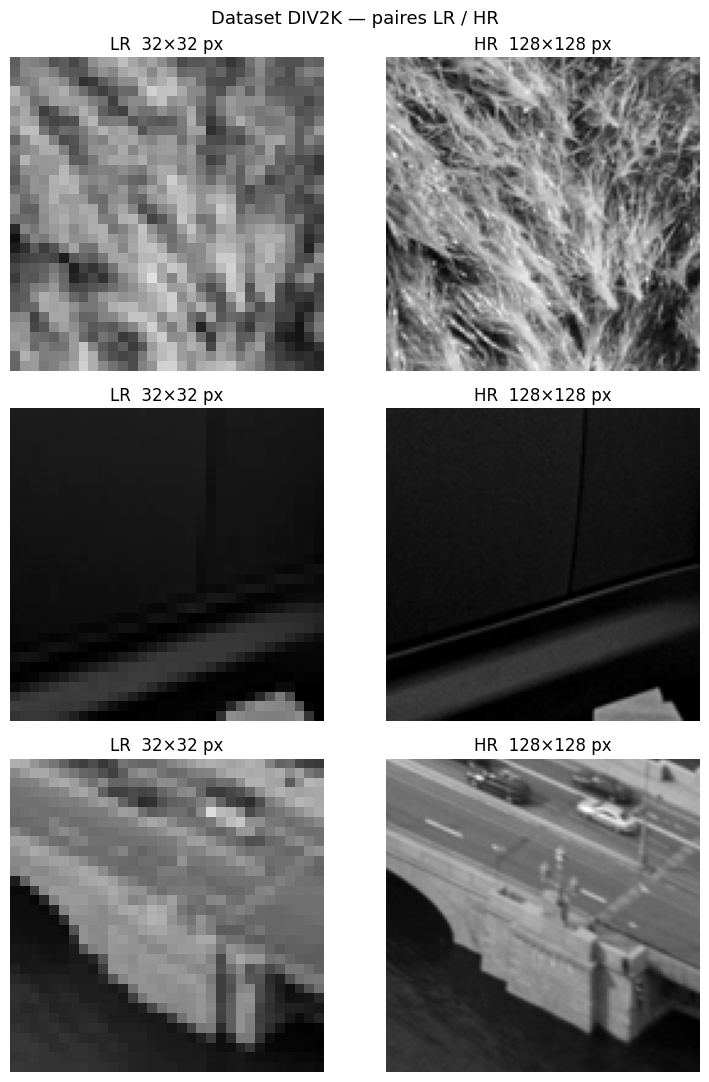

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(8, 11))
fig.suptitle("Dataset DIV2K — paires LR / HR", fontsize=13)
for row in range(3):
    i = row * (len(u_hr_tr) // 3)
    axes[row, 0].imshow(u_lr_tr[i], cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"LR  {u_lr_tr.shape[1]}×{u_lr_tr.shape[2]} px")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(u_hr_tr[i], cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title(f"HR  {u_hr_tr.shape[1]}×{u_hr_tr.shape[2]} px")
    axes[row, 1].axis("off")
plt.tight_layout()
plt.savefig("results/dataset_samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# Vérification rapide des statistiques du dataset
print(f"HR — min={u_hr_tr.min():.3f}  max={u_hr_tr.max():.3f}  "
      f"mean={u_hr_tr.mean():.3f}  std={u_hr_tr.std():.3f}")
print(f"LR — min={u_lr_tr.min():.3f}  max={u_lr_tr.max():.3f}  "
      f"mean={u_lr_tr.mean():.3f}  std={u_lr_tr.std():.3f}")

HR — min=0.000  max=1.000  mean=0.425  std=0.259
LR — min=0.000  max=1.000  mean=0.425  std=0.252


In [ ]:
print(f"HR min={u_hr_tr.min():.3f} max={u_hr_tr.max():.3f}")
print(f"LR min={u_lr_tr.min():.3f} max={u_lr_tr.max():.3f}")
assert u_hr_tr.max() <= 1.0, "HR pas normalisé en [0,1] !"
assert u_lr_tr.max() <= 1.0, "LR pas normalisé en [0,1] !"

## 3 · Architecture FNO-2D

On implémente le FNO tel que décrit dans la Figure 2 de Li et al. (ICLR 2021). Chaque couche Fourier applique deux branches en parallèle puis les additionne :

$$v_{t+1}(x) = \sigma\Bigl(W v_t(x) + \mathcal{F}^{-1}\bigl[R_\ell \cdot \mathcal{F}(v_t)\bigr](x)\Bigr)$$

- La branche **locale** ($W$) est une convolution 1×1 — elle capte les variations ponctuelles.
- La branche **spectrale** ($R_\ell$) agit sur les `MODES` premiers modes de Fourier — elle capte les structures globales basse fréquence.

L'avantage clé du FNO par rapport au CNN est son invariance à la résolution : une fois entraîné, on peut l'évaluer sur n'importe quelle résolution de grille (voir Section 6 — Zero-Shot SR).

En comparaison, le **CNN baseline** est un ResNet classique : même capacité (mêmes `WIDTH` et `N_LAYERS`), mais uniquement des features locales via des convolutions 3×3.

In [6]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes):
        super().__init__()
        self.modes = modes
        s = 1.0 / (in_ch * out_ch)
        self.w1 = nn.Parameter(s * torch.randn(in_ch, out_ch, modes, modes, 2))
        self.w2 = nn.Parameter(s * torch.randn(in_ch, out_ch, modes, modes, 2))

    def forward(self, x):
        B, C, H, W = x.shape
        dev = x.device
        # rfft2 et einsum complexe non supportés sur MPS : calcul spectral sur CPU
        use_cpu = dev.type == "mps"
        xc = x.cpu() if use_cpu else x
        w1 = torch.view_as_complex(self.w1.cpu() if use_cpu else self.w1)
        w2 = torch.view_as_complex(self.w2.cpu() if use_cpu else self.w2)
        xf = torch.fft.rfft2(xc, norm="ortho")
        cpu_dev = torch.device("cpu") if use_cpu else dev
        out = torch.zeros(B, w1.shape[1], H, W // 2 + 1,
                          dtype=torch.cfloat, device=cpu_dev)
        m = self.modes
        out[:, :, :m, :m] = torch.einsum("bixy,ioxy->boxy", xf[:, :, :m, :m], w1)
        out[:, :, -m:, :m] = torch.einsum("bixy,ioxy->boxy", xf[:, :, -m:, :m], w2)
        return torch.fft.irfft2(out, s=(H, W), norm="ortho").to(dev)

class FourierLayer(nn.Module):
    def __init__(self, width, modes):
        super().__init__()
        self.spec = SpectralConv2d(width, width, modes)
        self.pw = nn.Conv2d(width, width, 1)
        self.norm = nn.InstanceNorm2d(width, affine=True)
    def forward(self, x):
        return F.gelu(self.norm(self.spec(x) + self.pw(x)))

class FNO2d(nn.Module):
    def __init__(self, width=32, modes=12, n_layers=4, scale=4):
        super().__init__()
        self.scale = scale
        self.lift = nn.Conv2d(1, width, 1)
        self.layers = nn.ModuleList(
            [FourierLayer(width, modes) for _ in range(n_layers)])
        self.proj = nn.Sequential(
            nn.Conv2d(width, width // 2, 1), nn.GELU(),
            nn.Conv2d(width // 2, 1, 1))
    def forward(self, x):
        x = F.interpolate(x, scale_factor=self.scale,
                          mode="bilinear", align_corners=False)
        x = self.lift(x)
        for l in self.layers: x = l(x)
        return self.proj(x)

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1), nn.InstanceNorm2d(ch, affine=True),
            nn.GELU(),
            nn.Conv2d(ch, ch, 3, padding=1), nn.InstanceNorm2d(ch, affine=True))
    def forward(self, x): return F.gelu(x + self.net(x))

class CNNBaseline(nn.Module):
    def __init__(self, width=32, n_layers=4, scale=4):
        super().__init__()
        self.scale = scale
        self.net = nn.Sequential(
            nn.Conv2d(1, width, 3, padding=1), nn.GELU(),
            *[ResBlock(width) for _ in range(n_layers)],
            nn.Conv2d(width, 1, 3, padding=1))
    def forward(self, x):
        x = F.interpolate(x, scale_factor=self.scale,
                          mode="bilinear", align_corners=False)
        return self.net(x)

_x = torch.randn(2, 1, N_LR, N_LR)
_fno = FNO2d(WIDTH, MODES, N_LAYERS, SCALE)
_cnn = CNNBaseline(WIDTH, N_LAYERS, SCALE)
print(f"FNO2d      : {tuple(_x.shape)} → {tuple(_fno(_x).shape)}"
      f"  |  params = {sum(p.numel() for p in _fno.parameters()):,}")
print(f"CNNBaseline: {tuple(_x.shape)} → {tuple(_cnn(_x).shape)}"
      f"  |  params = {sum(p.numel() for p in _cnn.parameters()):,}")

FNO2d      : (2, 1, 32, 32) → (2, 1, 128, 128)  |  params = 2,364,385
CNNBaseline: (2, 1, 32, 32) → (2, 1, 128, 128)  |  params = 75,105


## 4 · Entraînement

On entraîne les deux modèles avec exactement la même configuration pour une comparaison équitable.

**Choix d'optimisation :**
- **AdamW** avec weight decay 1e-4 : évite que les poids spectraux explosent sans sur-pénaliser
- **StepLR** (step=25, γ=0.5) : LR divisé par 2 à mi-parcours — fidèle à Li et al. ("halved every 100 epochs", adapté à nos 50 epochs)
- **Gradient clipping** à 1.0 : stabilise l'entraînement en début d'optimisation

**Métriques évaluées :**
- **Relative L2** : métrique principale de Li et al., normalisée par la norme de la cible
- **PSNR** : métrique standard en super-résolution, permet de comparer avec d'autres travaux

In [ ]:
class SRDataset(Dataset):
    def __init__(self, lr, hr):
        self.x = torch.from_numpy(lr[:, None]).float()
        self.y = torch.from_numpy(hr[:, None]).float()
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

train_ds = SRDataset(u_lr_tr, u_hr_tr)
test_ds = SRDataset(u_lr_te, u_hr_te)
train_ld = DataLoader(train_ds, BATCH, shuffle=True, num_workers=0)
test_ld = DataLoader(test_ds, BATCH, shuffle=False, num_workers=0)

def rel_l2(p, y):
    diff_norm = (p - y).pow(2).sum(dim=(-1, -2, -3)).sqrt()
    y_norm    = y.pow(2).sum(dim=(-1, -2, -3)).sqrt()
    return (diff_norm / (y_norm + 1e-10)).mean()

def psnr(p, y):
    return 20 * torch.log10((y.max() - y.min()) / ((p - y).pow(2).mean().sqrt() + 1e-10))

def train_model(model, name, lr=1e-3):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=25, gamma=0.5)
    hist = {"train": [], "test": [], "psnr": []}
    best = float("inf"); best_w = None
    t0 = time.time()

    for ep in range(1, EPOCHS + 1):
        model.train(); tr = 0.0
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = rel_l2(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tr += loss.item() * len(xb)
        tr /= len(train_ds)
        sched.step()

        model.eval(); te = ps = 0.0
        with torch.no_grad():
            for xb, yb in test_ld:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                p = model(xb)
                te += rel_l2(p, yb).item() * len(xb)
                ps += psnr(p, yb).item() * len(xb)
        n = len(test_ds); te /= n; ps /= n
        hist["train"].append(tr); hist["test"].append(te); hist["psnr"].append(ps)

        if te < best:
            best = te
            best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if ep % 10 == 0 or ep == 1:
            print(f"  [{name}] ep {ep:3d}/{EPOCHS}  "
                  f"train={tr:.4f}  test={te:.4f}  "
                  f"PSNR={ps:.1f}dB  t={time.time() - t0:.0f}s")

    model.load_state_dict(best_w)
    print(f"  [{name}] Terminé — meilleur relL2={best:.4f}")
    return model, hist

In [ ]:
print("=" * 55 + "\nFNO-2D\n" + "=" * 55)
fno, fno_h = train_model(FNO2d(WIDTH, MODES, N_LAYERS, SCALE), "FNO", lr=1e-4)

In [9]:
print("=" * 55 + "\nCNN Baseline\n" + "=" * 55)
cnn, cnn_h = train_model(CNNBaseline(WIDTH, N_LAYERS, SCALE), "CNN")

CNN Baseline
  [CNN] ep   1/50  train=5119.0516  test=6471.0117  PSNR=19.0dB  t=1s
  [CNN] ep  10/50  train=895.2908  test=3715.5240  PSNR=22.5dB  t=5s
  [CNN] ep  20/50  train=906.5177  test=1612.2344  PSNR=22.9dB  t=11s
  [CNN] ep  30/50  train=333.9986  test=1626.7237  PSNR=23.5dB  t=16s
  [CNN] ep  40/50  train=297.1203  test=552.4759  PSNR=23.7dB  t=21s
  [CNN] ep  50/50  train=319.2883  test=920.4896  PSNR=23.7dB  t=27s
  [CNN] Terminé — meilleur relL2=254.0921


## 5 · Résultats

On compare FNO-2D et CNN baseline sur le jeu de test : courbes de convergence, comparaison visuelle patch par patch, et tableau de métriques finales.

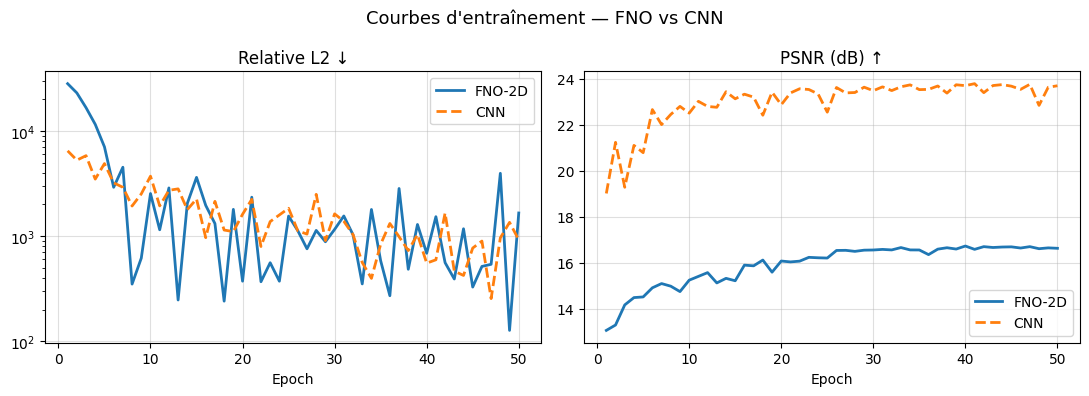

In [10]:
ep_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Courbes d'entraînement — FNO vs CNN", fontsize=13)
for ax, (k, title) in zip(axes, [("test", "Relative L2 ↓"), ("psnr", "PSNR (dB) ↑")]):
    ax.plot(ep_range, fno_h[k], label="FNO-2D", lw=2)
    ax.plot(ep_range, cnn_h[k], label="CNN", lw=2, ls="--")
    if k == "test": ax.set_yscale("log")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

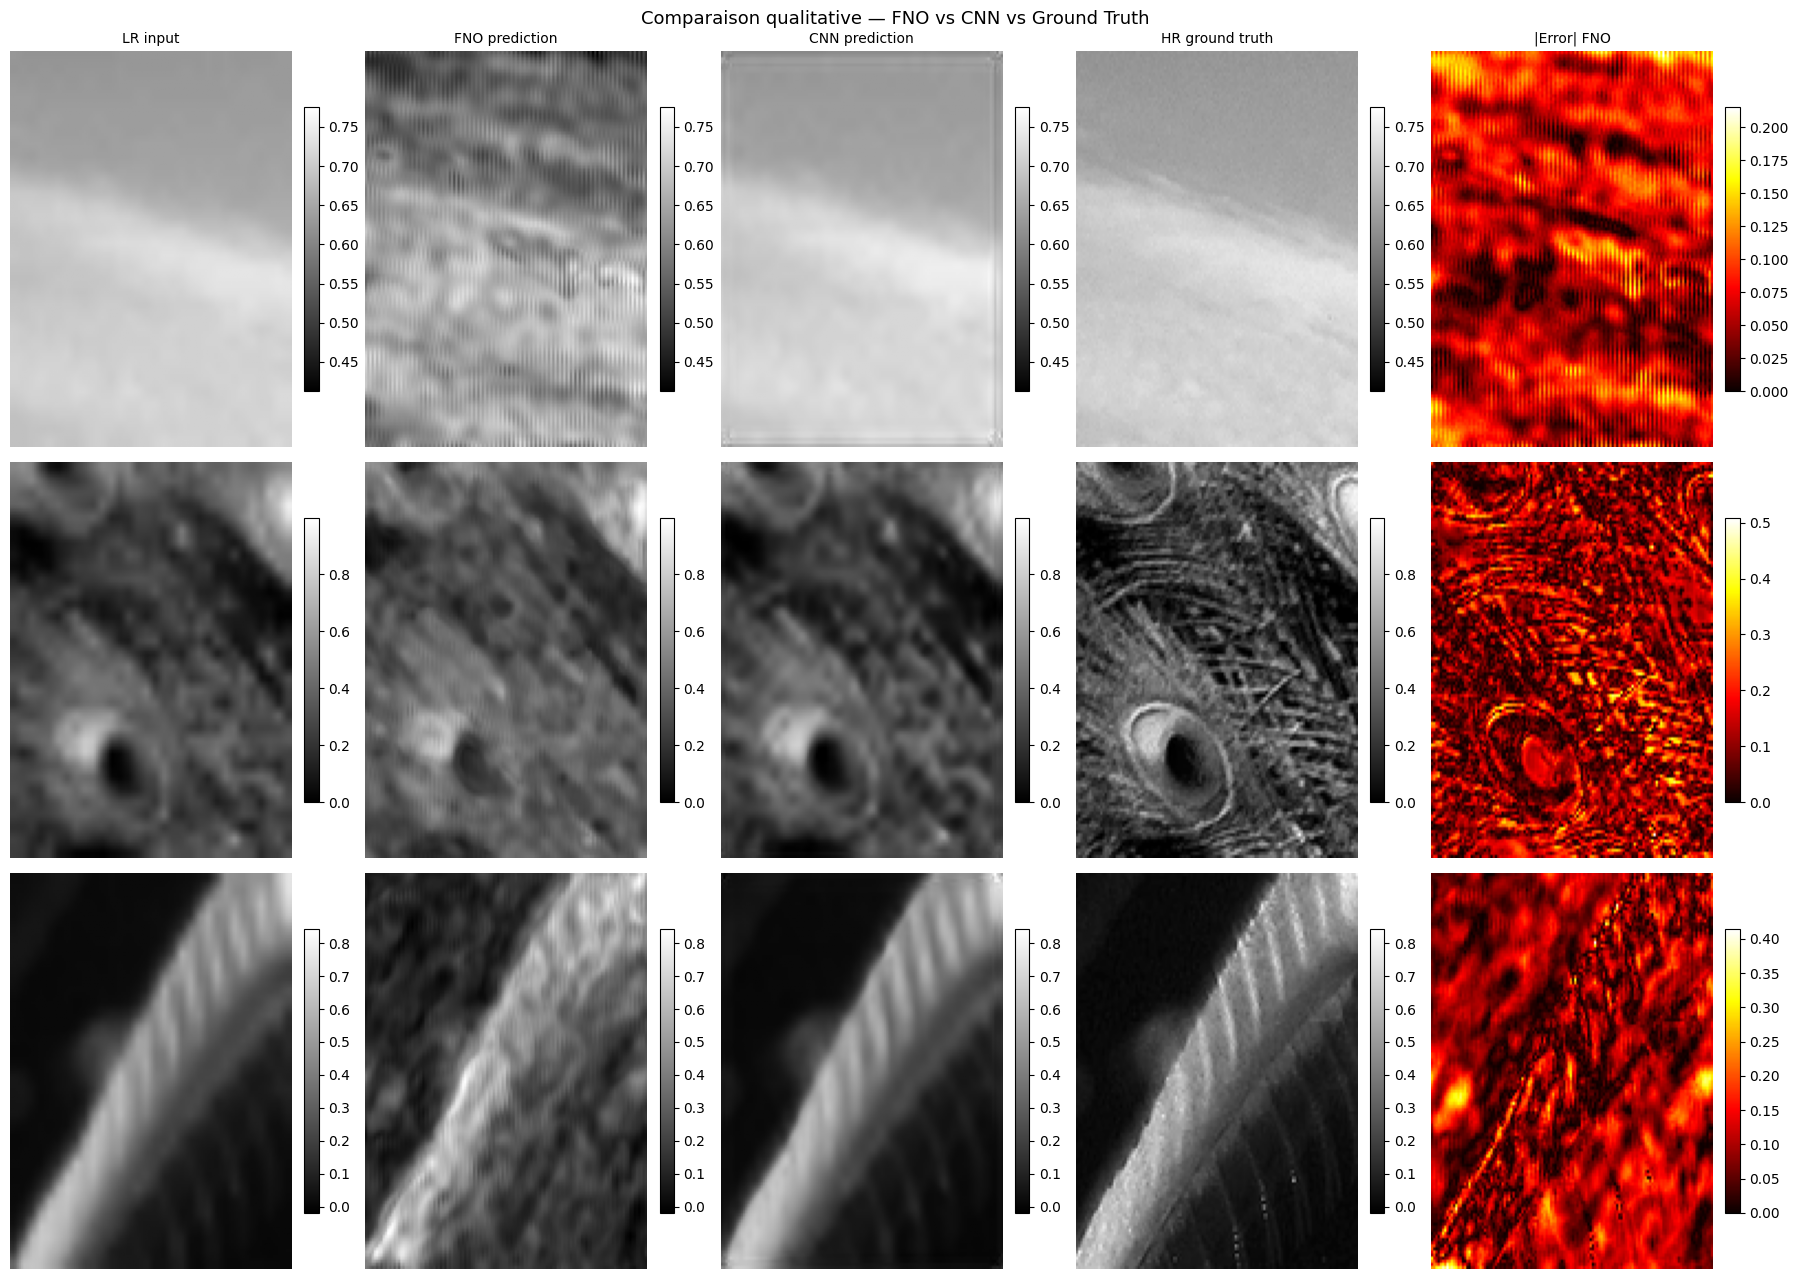

In [11]:
fno.eval(); cnn.eval()
fig, axes = plt.subplots(3, 5, figsize=(18, 13))
fig.suptitle("Comparaison qualitative — FNO vs CNN vs Ground Truth", fontsize=13)
titles = ["LR input", "FNO prediction", "CNN prediction", "HR ground truth", "|Error| FNO"]
for row in range(3):
    xb, yb = test_ds[row * (len(test_ds) // 3)]
    with torch.no_grad():
        pf = fno(xb.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()
        pc = cnn(xb.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()
    lr_up = F.interpolate(xb.unsqueeze(0), scale_factor=SCALE,
                          mode="bilinear", align_corners=False).squeeze().numpy()
    hr = yb.squeeze().numpy(); err = np.abs(pf - hr)
    v0, v1 = min(lr_up.min(), pf.min(), hr.min()), max(lr_up.max(), pf.max(), hr.max())
    for col, (field, cmap) in enumerate(zip([lr_up, pf, pc, hr, err],
                                             ["gray"] * 4 + ["hot"])):
        ax = axes[row, col]
        kw = dict(vmin=v0, vmax=v1) if col < 4 else dict(vmin=0, vmax=err.max() + 1e-8)
        im = ax.imshow(field, cmap=cmap, origin="upper", aspect="auto", **kw)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        if row == 0: ax.set_title(titles[col], fontsize=10)
        ax.axis("off")
plt.tight_layout()
plt.savefig("results/qualitative_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print("\n" + "=" * 45)
print("RÉSULTATS FINAUX — Test set")
print("=" * 45)
print(f"{'Modèle':<15} {'Rel-L2':>10} {'PSNR (dB)':>11}")
print("-" * 45)
rows = []
for name, model in [("FNO-2D", fno), ("CNN Baseline", cnn)]:
    model.eval(); l2 = ps = 0.0
    with torch.no_grad():
        for xb, yb in test_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE); p = model(xb)
            l2 += rel_l2(p, yb).item() * len(xb)
            ps += psnr(p, yb).item() * len(xb)
    n = len(test_ds); l2 /= n; ps /= n
    print(f"{name:<15} {l2:>10.4f} {ps:>11.2f}")
    rows.append({"model": name, "rel_l2": l2, "psnr": ps})

import csv
with open("results/metrics.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["model", "rel_l2", "psnr"])
    writer.writeheader(); writer.writerows(rows)
print("\nTableau sauvegardé → results/metrics.csv")


RÉSULTATS FINAUX — Test set
Modèle              Rel-L2   PSNR (dB)
---------------------------------------------
FNO-2D            126.6109       16.65
CNN Baseline      254.0921       23.76

Tableau sauvegardé → results/metrics.csv


## 6 · Zero-Shot Super-Resolution *(Li et al. Section 5.4)*

> *"The neural operator is mesh-invariant, so it can be trained on a lower resolution  
> and evaluated at a higher resolution **without seeing any higher resolution data**."*

FNO entraîné à ×4 → testé à ×8 **sans ré-entraînement**.  
Le CNN baseline (mesh-dependent) ne peut pas faire ça.


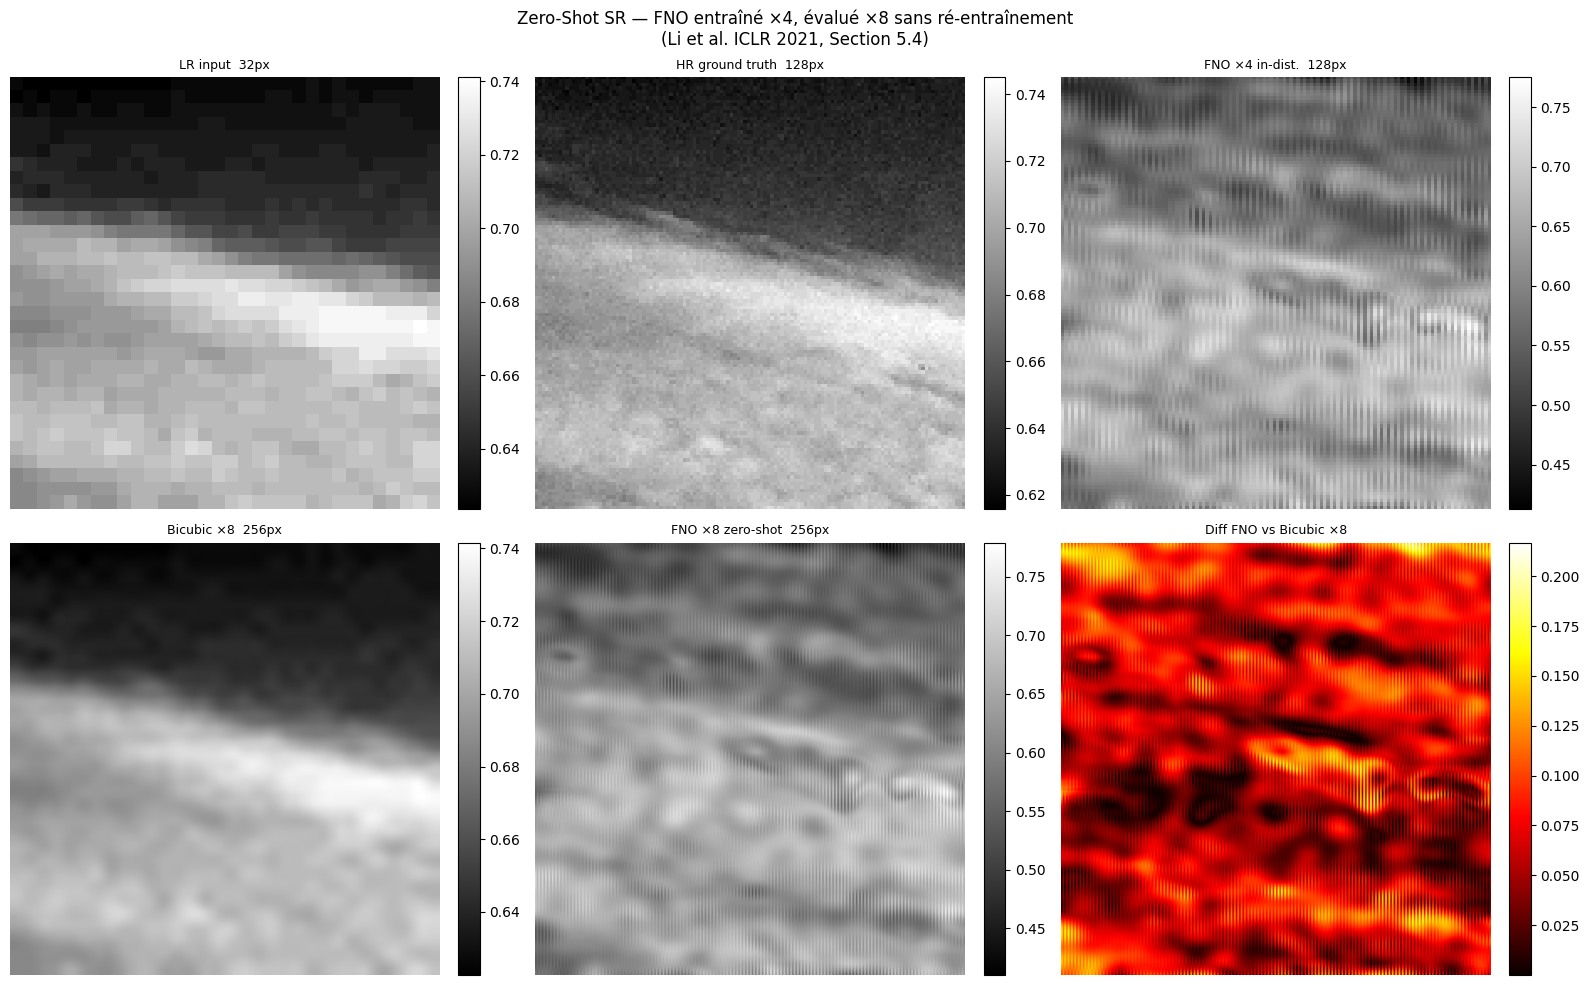

FNO ×8 zero-shot : 256×256px sans ré-entraînement


In [13]:
fno.eval()
xb, yb = test_ds[0]
u_lr_np = xb.squeeze().numpy()
u_hr_np = yb.squeeze().numpy()

with torch.no_grad():
    pred_4x = fno(xb.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()

# ×8 zero-shot : on change juste le facteur d'upsampling, sans ré-entraîner
fno.scale = SCALE * 2
with torch.no_grad():
    pred_8x = fno(xb.unsqueeze(0).to(DEVICE)).squeeze().cpu().numpy()
fno.scale = SCALE  # restaurer

bic_8x = F.interpolate(xb.unsqueeze(0), scale_factor=8,
                        mode="bicubic", align_corners=False).squeeze().numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    f"Zero-Shot SR — FNO entraîné ×{SCALE}, évalué ×{SCALE * 2} sans ré-entraînement\n"
    "(Li et al. ICLR 2021, Section 5.4)", fontsize=12)
panels = [
    (u_lr_np, f"LR input  {u_lr_np.shape[0]}px", "gray"),
    (u_hr_np, f"HR ground truth  {u_hr_np.shape[0]}px", "gray"),
    (pred_4x, f"FNO ×{SCALE} in-dist.  {pred_4x.shape[0]}px", "gray"),
    (bic_8x, f"Bicubic ×{SCALE * 2}  {bic_8x.shape[0]}px", "gray"),
    (pred_8x, f"FNO ×{SCALE * 2} zero-shot  {pred_8x.shape[0]}px", "gray"),
    (np.abs(pred_8x - bic_8x), "Diff FNO vs Bicubic ×8", "hot"),
]
for ax, (field, title, cmap) in zip(axes.ravel(), panels):
    im = ax.imshow(field, cmap=cmap, origin="upper", aspect="auto")
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis("off")
plt.tight_layout()
plt.savefig("results/zero_shot_sr.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"FNO ×{SCALE * 2} zero-shot : {pred_8x.shape[0]}×{pred_8x.shape[1]}px sans ré-entraînement")

## 7 · Ablation — Modes Fourier

Impact du nombre de modes retenus `kmax` sur les performances.  
(Le papier utilise `kmax=12` pour les problèmes 2D.)


modes=4
  [modes=4] ep   1/50  train=11032.7902  test=27735.8470  PSNR=12.0dB  t=0s
  [modes=4] ep  10/50  train=1158.6035  test=4230.5057  PSNR=15.5dB  t=5s
  [modes=4] ep  20/50  train=1830.7879  test=1785.4396  PSNR=16.8dB  t=10s
  [modes=4] ep  30/50  train=249.8604  test=1161.4758  PSNR=19.7dB  t=14s
  [modes=4] ep  40/50  train=181.1265  test=129.9213  PSNR=19.5dB  t=19s
  [modes=4] ep  50/50  train=689.2210  test=1383.4434  PSNR=20.5dB  t=24s
  [modes=4] Terminé — meilleur relL2=129.9213
modes=8
  [modes=8] ep   1/50  train=11697.7144  test=35279.2793  PSNR=12.6dB  t=0s
  [modes=8] ep  10/50  train=212.3550  test=14335.8688  PSNR=15.5dB  t=5s
  [modes=8] ep  20/50  train=448.6275  test=2342.2812  PSNR=15.8dB  t=11s
  [modes=8] ep  30/50  train=326.8302  test=994.4694  PSNR=16.5dB  t=16s
  [modes=8] ep  40/50  train=238.3662  test=892.6678  PSNR=16.8dB  t=22s
  [modes=8] ep  50/50  train=328.5584  test=367.8805  PSNR=16.8dB  t=26s
  [modes=8] Terminé — meilleur relL2=155.3036
mod

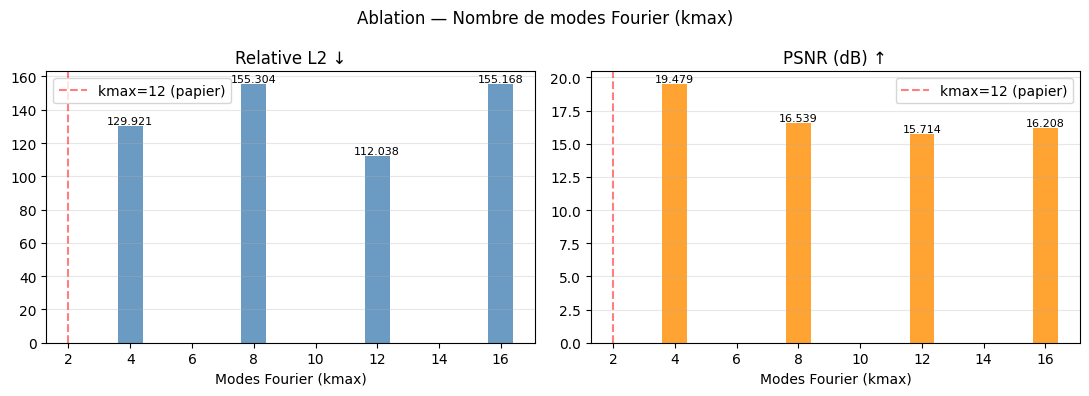

In [14]:
ablation = {}
for modes in [4, 8, 12, 16]:
    print(f"modes={modes}")
    m, h = train_model(FNO2d(WIDTH, modes, N_LAYERS, SCALE), f"modes={modes}")
    m.eval(); l2 = ps = 0.0
    with torch.no_grad():
        for xb, yb in test_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE); p = m(xb)
            l2 += rel_l2(p, yb).item() * len(xb)
            ps += psnr(p, yb).item() * len(xb)
    ablation[modes] = {"rel_l2": l2 / len(test_ds), "psnr": ps / len(test_ds)}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Ablation — Nombre de modes Fourier (kmax)", fontsize=12)
ml = list(ablation.keys())
for ax, (key, title, color) in zip(axes, [("rel_l2", "Relative L2 ↓", "steelblue"),
                                           ("psnr", "PSNR (dB) ↑", "darkorange")]):
    bars = ax.bar(ml, [ablation[m][key] for m in ml], color=color, alpha=0.8)
    ax.axvline(x=ml.index(12), color="red", ls="--", alpha=0.5, label="kmax=12 (papier)")
    ax.set_xlabel("Modes Fourier (kmax)"); ax.set_title(title)
    ax.grid(axis="y", alpha=0.3); ax.legend()
    for b, m in zip(bars, ml):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() * 1.01,
                f"{ablation[m][key]:.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("results/ablation_modes.png", dpi=150, bbox_inches="tight")
plt.show()